# Laboratorio #6 – Transfer Learning y Fine-Tuning
**CC3092 – Deep Learning y Sistemas Inteligentes**

Este notebook cubre:
- **Parte 2:** exploración y preparación de CIFAR-10.
- **Parte 4 (modelo 1):** CNN desde cero en PyTorch, con iteraciones, métricas, curvas de pérdida, evaluación final en test y el experimento 4.1 (fracción reducida de datos).

> Los modelos VGG-16 (feature extractor y fine-tuning) se agregan después reutilizando las utilidades de entrenamiento y evaluación definidas aquí.

## 0. Configuración

In [1]:
import time, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## 1. Carga del dataset

In [2]:
# Datasets "crudos" (imágenes PIL) para exploración
train_raw = datasets.CIFAR10(root="data", train=True, download=True)
test_raw  = datasets.CIFAR10(root="data", train=False, download=True)

class_names = train_raw.classes
y_train_all = np.array(train_raw.targets)
y_test = np.array(test_raw.targets)
print(class_names)

100%|██████████| 170M/170M [25:42<00:00, 111kB/s]  


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Exploración de los datos

### 2.1 Número de observaciones, clases y balance

Observaciones train (original): 50,000
Observaciones test (oficial):   10,000
Número de clases: 10


,clase,train,test
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


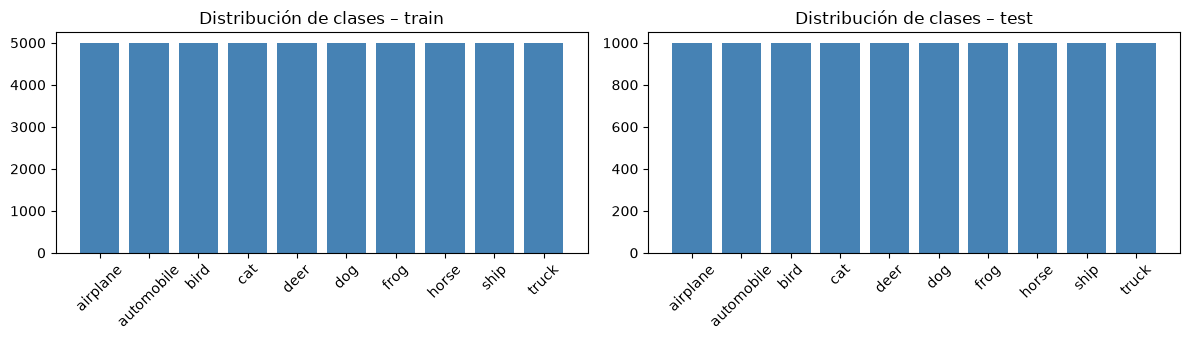

In [3]:
print(f"Observaciones train (original): {len(train_raw):,}")
print(f"Observaciones test (oficial):   {len(test_raw):,}")
print(f"Número de clases: {len(class_names)}")

counts = pd.DataFrame({
    "clase": class_names,
    "train": np.bincount(y_train_all),
    "test": np.bincount(y_test),
})
display(counts)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
for a, col in zip(ax, ["train", "test"]):
    a.bar(counts["clase"], counts[col], color="steelblue")
    a.set_title(f"Distribución de clases – {col}")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

**Respuesta:** CIFAR-10 tiene 50,000 imágenes de entrenamiento y 10,000 de test, en 10 clases. Las clases están **perfectamente balanceadas** (5,000 por clase en train y 1,000 en test), por lo que accuracy es una métrica razonable, aunque igual se reportan precision, recall y F1 macro.

### 2.2 Resolución, canales y estadísticas por canal

In [4]:
X_train = train_raw.data            # (50000, 32, 32, 3) uint8
print("Shape del arreglo de train:", X_train.shape)
print("Resolución:", X_train.shape[1:3], "| Canales:", X_train.shape[3], "| dtype:", X_train.dtype)

cifar_mean = (X_train / 255.0).mean(axis=(0, 1, 2))
cifar_std  = (X_train / 255.0).std(axis=(0, 1, 2))
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std  = np.array([0.229, 0.224, 0.225])

stats = pd.DataFrame({
    "CIFAR-10 mean": cifar_mean, "ImageNet mean": imagenet_mean,
    "CIFAR-10 std": cifar_std,   "ImageNet std": imagenet_std,
}, index=["R", "G", "B"]).round(4)
display(stats)

CIFAR_MEAN, CIFAR_STD = tuple(cifar_mean.tolist()), tuple(cifar_std.tolist())
IMAGENET_MEAN, IMAGENET_STD = tuple(imagenet_mean.tolist()), tuple(imagenet_std.tolist())

Shape del arreglo de train: (50000, 32, 32, 3)
Resolución: (32, 32) | Canales: 3 | dtype: uint8


,CIFAR-10 mean,ImageNet mean,CIFAR-10 std,ImageNet std
R,0.4914,0.485,0.2470,0.229
G,0.4822,0.456,0.2435,0.224
B,0.4465,0.406,0.2616,0.225


**Respuesta:** las imágenes son de **32×32 píxeles con 3 canales (RGB)**. Las estadísticas de CIFAR-10 son cercanas a las de ImageNet, pero no idénticas: la media de CIFAR-10 es ligeramente mayor (~0.49, 0.48, 0.45 vs 0.485, 0.456, 0.406) y su desviación estándar también es mayor (~0.25 vs ~0.225). Para la CNN desde cero se normaliza con las estadísticas propias de CIFAR-10. Para VGG-16 se usan las de ImageNet, porque el backbone fue preentrenado con esa distribución de entrada.

### 2.3 Ejemplos por clase

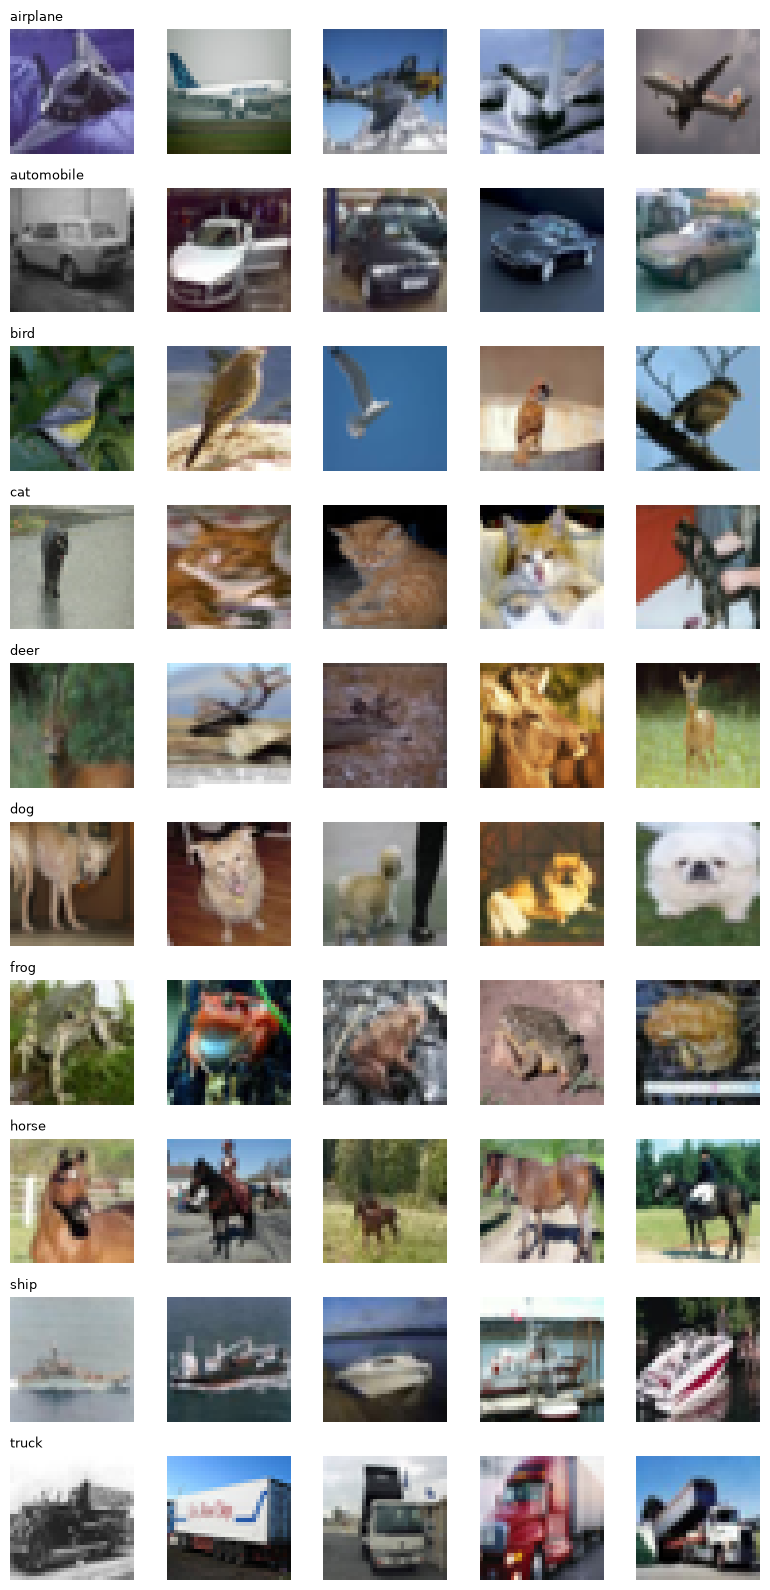

In [5]:
n_per_class = 5
fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(n_per_class * 1.6, len(class_names) * 1.6))
rng = np.random.default_rng(SEED)
for c, name in enumerate(class_names):
    idxs = rng.choice(np.where(y_train_all == c)[0], n_per_class, replace=False)
    for j, i in enumerate(idxs):
        axes[c, j].imshow(X_train[i]); axes[c, j].axis("off")
    axes[c, 0].set_title(name, fontsize=9, loc="left")
plt.tight_layout(); plt.show()

**Pares de clases que esperamos más difíciles de distinguir:**
- **cat ↔ dog:** ambos son cuadrúpedos con pelaje, tamaños y poses similares; a 32×32 los rasgos finos (hocico, orejas) casi se pierden.
- **automobile ↔ truck:** formas rectangulares, ruedas y fondos de carretera parecidos; varían sobre todo en tamaño relativo.
- **deer ↔ horse:** siluetas y proporciones parecidas y fondos naturales (pasto, bosque).
- **airplane ↔ ship (y bird ↔ airplane):** fondos casi uniformes (cielo o mar azul) que hacen que el contexto sea engañoso.

Esto se verifica luego con las matrices de confusión.

### 2.4 Pipelines de preprocesamiento

In [6]:
# Augmentation (solo train) - opera sobre la imagen PIL
augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),          # traslaciones pequeñas
    transforms.RandomHorizontalFlip(p=0.5),        # espejo horizontal
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

# --- CNN desde cero: resolución nativa 32x32, normalización con estadísticas de CIFAR-10
to_tensor_cnn = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
cnn_train_tf = transforms.Compose([augment, to_tensor_cnn])   # con augmentation
cnn_noaug_tf = to_tensor_cnn                                  # sin augmentation
cnn_eval_tf  = to_tensor_cnn                                  # val / test

# --- VGG-16 (para uso posterior): resize + normalización ImageNet
VGG_RES = 224   # puede bajarse a 128 o 112 si hay restricciones de cómputo (misma para ambos modelos VGG)
vgg_eval_tf = transforms.Compose([
    transforms.Resize(VGG_RES), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
vgg_train_tf = transforms.Compose([
    augment, transforms.Resize(VGG_RES), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

# Costo de pasar de 32x32 a resoluciones mayores
rows = []
for r in [32, 112, 128, 224]:
    rows.append({"resolución": f"{r}x{r}", "píxeles/imagen": r * r, "veces vs 32x32": (r * r) / (32 * 32)})
display(pd.DataFrame(rows))

,resolución,píxeles/imagen,veces vs 32x32
0,32x32,1024,1.00
1,112x112,12544,12.25
2,128x128,16384,16.00
3,224x224,50176,49.00


**Pasar de 32×32 a 224×224:** la imagen tiene 1,024 píxeles y pasa a 50,176, es decir **49 veces más píxeles**. Las activaciones intermedias y las operaciones de las capas convolucionales escalan de forma similar (los FLOPs por imagen y la memoria de activaciones crecen ~49×). Por eso la CNN pequeña entrena rápido en resolución nativa, mientras que VGG-16 a 224×224 es mucho más costoso. Usar 112 o 128 reduce el costo entre ~3× y ~4× frente a 224.

### 2.5 Data augmentation

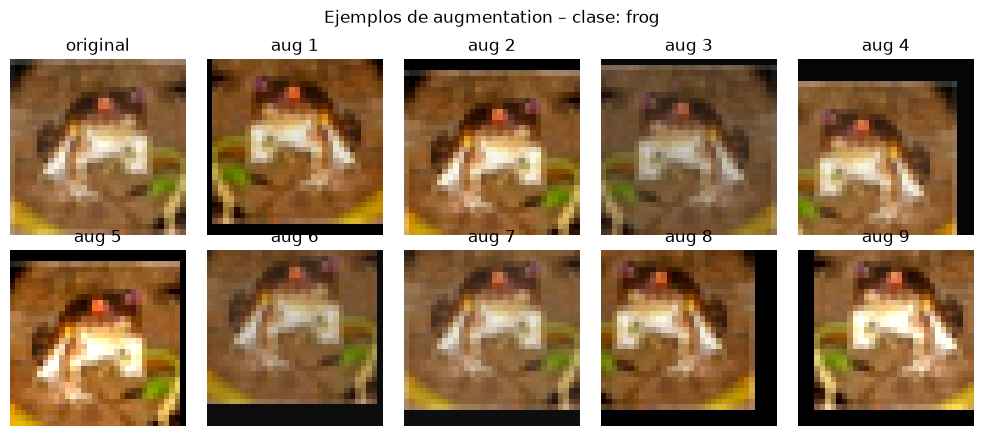

In [7]:
sample_img, sample_lbl = train_raw[0]
fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
axes[0, 0].imshow(sample_img); axes[0, 0].set_title("original"); axes[0, 0].axis("off")
for k in range(1, 10):
    ax = axes.flat[k]
    ax.imshow(augment(sample_img)); ax.set_title(f"aug {k}"); ax.axis("off")
plt.suptitle(f"Ejemplos de augmentation – clase: {class_names[sample_lbl]}")
plt.tight_layout(); plt.show()

**Técnicas usadas y por qué:**
- **RandomCrop con padding=4:** simula pequeñas traslaciones y hace al modelo robusto a la posición del objeto.
- **RandomHorizontalFlip:** un objeto espejado sigue siendo de la misma clase (no se usa flip vertical, porque un barco o un caballo al revés no es una imagen natural).
- **ColorJitter suave:** da robustez a cambios de iluminación y color sin destruir la información de clase.

**¿Por qué solo en entrenamiento?** La augmentation actúa como regularizador: aumenta la variedad de lo que ve el modelo al aprender. En validación y test se quiere medir el rendimiento sobre datos reales, sin modificar y de forma determinista y reproducible. Aumentar esos conjuntos alteraría la distribución de evaluación y haría las métricas ruidosas e incomparables entre modelos.

### 2.6 Split estratificado: train / validación / test

In [8]:
idx_all = np.arange(len(train_raw))
train_idx, val_idx = train_test_split(
    idx_all, test_size=5000, stratify=y_train_all, random_state=SEED)
print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test (oficial): {len(test_raw):,}")
print("Por clase en train:", np.bincount(y_train_all[train_idx]))
print("Por clase en val:  ", np.bincount(y_train_all[val_idx]))

# Mismos datos base, distinta transformación según el rol del subconjunto
ds_train_aug   = datasets.CIFAR10("data", train=True,  transform=cnn_train_tf, download=False)
ds_train_noaug = datasets.CIFAR10("data", train=True,  transform=cnn_noaug_tf, download=False)
ds_val         = datasets.CIFAR10("data", train=True,  transform=cnn_eval_tf,  download=False)
ds_test        = datasets.CIFAR10("data", train=False, transform=cnn_eval_tf,  download=False)

BATCH_SIZE = 128
NUM_WORKERS = 2      # poner 0 si hay problemas en Windows
PIN = device.type == "cuda"

def make_loader(ds, indices=None, shuffle=False, batch_size=BATCH_SIZE):
    d = Subset(ds, indices) if indices is not None else ds
    return DataLoader(d, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=PIN)

val_loader  = make_loader(ds_val, val_idx)
test_loader = make_loader(ds_test)

Train: 45,000 | Val: 5,000 | Test (oficial): 10,000
Por clase en train: [4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]
Por clase en val:   [500 500 500 500 500 500 500 500 500 500]


## 3. Utilidades de entrenamiento y evaluación
Estas funciones son reutilizables para los modelos VGG-16. Registran, por iteración, la configuración, las pérdidas por epoch, las métricas de validación, el número de parámetros, el tiempo por epoch y total, y la memoria pico de GPU.

In [9]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, n = 0.0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        out = model(x)
        total_loss += criterion(out, y).item() * x.size(0)
        n += x.size(0)
        all_preds.append(out.argmax(1).cpu()); all_labels.append(y.cpu())
    return total_loss / n, torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

def compute_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": p, "recall_macro": r, "f1_macro": f1}

def train_model(model, train_loader, val_loader, cfg, verbose=True):
    """Entrena con AdamW; guarda los mejores pesos según la pérdida de validación."""
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"],
                                  weight_decay=cfg.get("weight_decay", 0.0))
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
                 if cfg.get("scheduler") == "cosine" else None)
    use_amp = cfg.get("amp", True) and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    patience = cfg.get("patience", None)

    history = {"train_loss": [], "val_loss": [], "epoch_time": []}
    best_val, best_state, best_epoch, bad = float("inf"), None, 0, 0

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    t_start = time.time()

    for epoch in range(1, cfg["epochs"] + 1):
        t0 = time.time()
        model.train()
        running, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            running += loss.item() * x.size(0); n += x.size(0)
        if scheduler: scheduler.step()

        train_loss = running / n
        val_loss, _, _ = evaluate(model, val_loader, criterion)
        if device.type == "cuda": torch.cuda.synchronize()
        dt = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["epoch_time"].append(dt)

        if val_loss < best_val:
            best_val, best_epoch, bad = val_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad += 1

        if verbose:
            print(f"Epoch {epoch:03d}/{cfg['epochs']} | train {train_loss:.4f} | val {val_loss:.4f} | {dt:.1f}s")
        if patience and bad >= patience:
            print(f"Early stopping en epoch {epoch} (mejor: {best_epoch})")
            break

    total_time = time.time() - t_start
    peak_mem = torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else float("nan")
    model.load_state_dict(best_state)
    return history, best_state, best_epoch, total_time, peak_mem

## 4. Modelo 1: CNN desde cero
Arquitectura con **bloques convolucionales** `[Conv → BN → ReLU] × 2 → MaxPool → Dropout`, seguidos de un clasificador totalmente conectado con dropout. Los canales, el dropout y la cantidad de bloques son configurables para iterar.

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, convs=2, p_drop=0.0):
        super().__init__()
        layers = []
        for i in range(convs):
            layers += [nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1, bias=False),
                       nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        layers += [nn.MaxPool2d(2), nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity()]
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class CNNScratch(nn.Module):
    def __init__(self, channels=(32, 64, 128), convs_per_block=2, dropout_conv=0.1,
                 dropout_fc=0.5, fc_units=256, num_classes=10, in_ch=3, img_size=32):
        super().__init__()
        blocks, c_in = [], in_ch
        for c in channels:
            blocks.append(ConvBlock(c_in, c, convs_per_block, dropout_conv)); c_in = c
        self.features = nn.Sequential(*blocks)
        spatial = img_size // (2 ** len(channels))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c_in * spatial * spatial, fc_units), nn.BatchNorm1d(fc_units), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc),
            nn.Linear(fc_units, num_classes))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x): return self.classifier(self.features(x))

# Chequeo rápido de dimensiones
m = CNNScratch()
print(m(torch.randn(2, 3, 32, 32)).shape, "| params (total, entrenables):", count_params(m))

torch.Size([2, 10]) | params (total, entrenables): (815082, 815082)


### 4.1 Iteraciones de hiperparámetros
Se prueban 4 configuraciones para identificar overfitting y underfitting:

| Iteración | Idea |
|---|---|
| `cnn_base_noaug` | Baseline sin augmentation ni regularización conv (esperamos overfitting) |
| `cnn_base_aug` | Mismo modelo con augmentation + dropout conv |
| `cnn_wide_aug` | Más canales, weight decay y scheduler coseno |
| `cnn_wide_reg` | Más regularización (dropout conv/wd) y más epochs |

In [11]:
experiments = {
    "cnn_base_noaug": dict(channels=(32, 64, 128), convs_per_block=2, dropout_conv=0.0, dropout_fc=0.5,
                           fc_units=256, lr=1e-3, weight_decay=0.0, scheduler=None,
                           epochs=20, augment=False),
    "cnn_base_aug":   dict(channels=(32, 64, 128), convs_per_block=2, dropout_conv=0.1, dropout_fc=0.5,
                           fc_units=256, lr=1e-3, weight_decay=5e-4, scheduler=None,
                           epochs=30, augment=True),
    "cnn_wide_aug":   dict(channels=(64, 128, 256), convs_per_block=2, dropout_conv=0.2, dropout_fc=0.5,
                           fc_units=512, lr=2e-3, weight_decay=5e-4, scheduler="cosine",
                           epochs=40, augment=True),
    "cnn_wide_reg":   dict(channels=(64, 128, 256), convs_per_block=2, dropout_conv=0.3, dropout_fc=0.5,
                           fc_units=512, lr=2e-3, weight_decay=1e-3, scheduler="cosine",
                           epochs=50, augment=True),
}

MODEL_KEYS = ["channels", "convs_per_block", "dropout_conv", "dropout_fc", "fc_units"]
runs = {}   # nombre -> dict con history, estado, métricas, etc.

def get_train_loader(cfg, indices):
    ds = ds_train_aug if cfg["augment"] else ds_train_noaug
    return make_loader(ds, indices, shuffle=True)

def run_experiment(name, cfg, train_indices=train_idx, verbose=True):
    print(f"\n{'='*70}\n{name}\n{cfg}\n{'='*70}")
    set_seed()
    model = CNNScratch(**{k: cfg[k] for k in MODEL_KEYS})
    total_p, train_p = count_params(model)
    tr_loader = get_train_loader(cfg, train_indices)
    history, best_state, best_epoch, total_time, peak_mem = train_model(model, tr_loader, val_loader, cfg, verbose)

    val_loss, y_pred, y_true = evaluate(model, val_loader, nn.CrossEntropyLoss())
    metrics = compute_metrics(y_true, y_pred)
    runs[name] = dict(cfg=cfg, history=history, best_state=best_state, best_epoch=best_epoch,
                      metrics=metrics, val_loss=val_loss, total_params=total_p, trainable_params=train_p,
                      mean_epoch_time=float(np.mean(history["epoch_time"])),
                      total_time=total_time, peak_mem_mb=peak_mem)
    print(f"-> Val: {metrics} | mejor epoch: {best_epoch} | tiempo total: {total_time:.0f}s")

In [12]:
for name, cfg in experiments.items():
    run_experiment(name, cfg)


cnn_base_noaug
{'channels': (32, 64, 128), 'convs_per_block': 2, 'dropout_conv': 0.0, 'dropout_fc': 0.5, 'fc_units': 256, 'lr': 0.001, 'weight_decay': 0.0, 'scheduler': None, 'epochs': 20, 'augment': False}
Epoch 001/20 | train 1.3517 | val 0.9388 | 157.8s
Epoch 002/20 | train 0.8683 | val 0.8254 | 146.9s
Epoch 003/20 | train 0.6948 | val 0.7878 | 148.8s
Epoch 004/20 | train 0.5860 | val 0.6388 | 147.4s
Epoch 005/20 | train 0.4980 | val 0.6791 | 152.8s
Epoch 006/20 | train 0.4164 | val 0.6760 | 145.0s
Epoch 007/20 | train 0.3451 | val 0.6912 | 146.7s
Epoch 008/20 | train 0.2901 | val 0.6729 | 146.7s
Epoch 009/20 | train 0.2336 | val 0.6506 | 148.6s
Epoch 010/20 | train 0.1931 | val 0.6845 | 146.0s
Epoch 011/20 | train 0.1721 | val 0.7966 | 149.9s
Epoch 012/20 | train 0.1531 | val 0.6858 | 149.3s
Epoch 013/20 | train 0.1219 | val 0.7165 | 144.2s
Epoch 014/20 | train 0.1136 | val 0.9137 | 149.7s
Epoch 015/20 | train 0.1073 | val 0.8124 | 165.9s
Epoch 016/20 | train 0.0949 | val 0.8996 |

KeyboardInterrupt: 

### 4.2 Resumen de iteraciones (validación)

In [ ]:
def summary_table(run_names):
    rows = []
    for n in run_names:
        r = runs[n]
        rows.append({
            "iteración": n,
            "acc": r["metrics"]["accuracy"], "precision": r["metrics"]["precision_macro"],
            "recall": r["metrics"]["recall_macro"], "F1 macro": r["metrics"]["f1_macro"],
            "val loss": r["val_loss"], "mejor epoch": r["best_epoch"],
            "params totales": r["total_params"], "params entrenables": r["trainable_params"],
            "s/epoch": r["mean_epoch_time"], "tiempo total (s)": r["total_time"],
            "mem pico GPU (MB)": r["peak_mem_mb"],
        })
    return pd.DataFrame(rows).set_index("iteración")

results_df = summary_table(list(experiments))
display(results_df.style.format({"acc": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}", "F1 macro": "{:.4f}",
                                 "val loss": "{:.4f}", "s/epoch": "{:.1f}", "tiempo total (s)": "{:.0f}",
                                 "mem pico GPU (MB)": "{:.0f}", "params totales": "{:,}", "params entrenables": "{:,}"}))

# Hiperparámetros por iteración
display(pd.DataFrame({n: r["cfg"] for n, r in runs.items()}).T)

### 4.3 Curvas de pérdida (train vs validación)

In [ ]:
def plot_curves(run_names):
    fig, axes = plt.subplots(1, len(run_names), figsize=(5 * len(run_names), 3.8), squeeze=False)
    for ax, n in zip(axes[0], run_names):
        h = runs[n]["history"]
        ep = range(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], label="train")
        ax.plot(ep, h["val_loss"], label="val")
        ax.axvline(runs[n]["best_epoch"], ls="--", c="gray", lw=0.8, label="mejor epoch")
        ax.set_title(n); ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_curves(list(experiments))

**Interpretación** *(completar con los resultados obtenidos)*:
- `cnn_base_noaug`: si la pérdida de train sigue bajando mientras la de validación sube, hay **overfitting**.
- `cnn_base_aug`: la augmentation debería cerrar la brecha train-val.
- `cnn_wide_*`: un modelo más grande con más regularización debería bajar la pérdida de validación. Si ambas curvas se mantienen altas y juntas, sería **underfitting**.

### 4.4 Mejor configuración (según F1 macro en validación)

In [ ]:
best_name = results_df["F1 macro"].idxmax()
print("Mejor iteración:", best_name)
print(runs[best_name]["cfg"])

## 5. Evaluación final en test (una única vez)
Se carga el mejor modelo (pesos del mejor epoch por pérdida de validación) y se evalúa en el test oficial.

In [ ]:
best_cfg = runs[best_name]["cfg"]
final_model = CNNScratch(**{k: best_cfg[k] for k in MODEL_KEYS}).to(device)
final_model.load_state_dict(runs[best_name]["best_state"])

test_loss, y_pred_test, y_true_test = evaluate(final_model, test_loader, nn.CrossEntropyLoss())
test_metrics = compute_metrics(y_true_test, y_pred_test)
print(f"Test loss: {test_loss:.4f}")
print(pd.Series(test_metrics).round(4))
print()
print(classification_report(y_true_test, y_pred_test, target_names=class_names, digits=4))

In [ ]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title(title)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    plt.colorbar(im); plt.tight_layout(); plt.show()
    return cm

cm = plot_confusion(y_true_test, y_pred_test, f"CNN desde cero – matriz de confusión (test) – {best_name}")

# Pares más confundidos
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
top = np.dstack(np.unravel_index(np.argsort(-cm_off.ravel())[:5], cm.shape))[0]
print("Pares más confundidos (real -> predicho):")
for i, j in top:
    print(f"  {class_names[i]} -> {class_names[j]}: {cm[i, j]}")

## 6. Experimento adicional 4.1: efecto de la cantidad de datos (CNN desde cero)
Se reentrena la mejor configuración con solo el **10 % del conjunto de entrenamiento** (estratificado por clase) y se evalúa sobre el mismo test. Se mantienen las mismas validación y test.

In [ ]:
FRACTION = 0.10
small_idx, _ = train_test_split(train_idx, train_size=FRACTION, stratify=y_train_all[train_idx], random_state=SEED)
print(f"Subconjunto: {len(small_idx):,} imágenes | por clase: {np.bincount(y_train_all[small_idx])}")

run_experiment("cnn_best_10pct", best_cfg, train_indices=small_idx)

small_model = CNNScratch(**{k: best_cfg[k] for k in MODEL_KEYS}).to(device)
small_model.load_state_dict(runs["cnn_best_10pct"]["best_state"])
_, y_pred_small, y_true_small = evaluate(small_model, test_loader, nn.CrossEntropyLoss())
small_metrics = compute_metrics(y_true_small, y_pred_small)

comparison = pd.DataFrame({"100% datos": test_metrics, f"{int(FRACTION*100)}% datos": small_metrics}).T
comparison["n train"] = [len(train_idx), len(small_idx)]
comparison["tiempo total (s)"] = [runs[best_name]["total_time"], runs["cnn_best_10pct"]["total_time"]]
display(comparison.round(4))
plot_curves(["cnn_best_10pct"])
_ = plot_confusion(y_true_small, y_pred_small, "CNN desde cero – 10% de los datos (test)")

**Discusión** *(completar)*: comparar la caída de accuracy/F1 al usar solo 10 % de los datos. Con menos datos se espera más brecha train-val (overfitting), y una CNN entrenada desde cero suele degradarse más que un modelo preentrenado.

## 7. Guardado de resultados para comparar luego con VGG-16

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)
torch.save({"cfg": best_cfg, "state_dict": runs[best_name]["best_state"]}, "outputs/cnn_scratch_best.pt")
results_df.to_csv("outputs/cnn_scratch_val_results.csv")
comparison.to_csv("outputs/cnn_scratch_data_fraction.csv")
np.save("outputs/split_train_idx.npy", train_idx); np.save("outputs/split_val_idx.npy", val_idx)
print("Guardado en ./outputs")